In [24]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [25]:
#define state
class BMIState(TypedDict):
    weight_kg: float
    height_m:float
    bmi: float
    category: str
    

In [26]:
def calculate_bmi(state:BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight/(height**2)
    state['bmi'] =round(bmi,2)
    return state
def select_category(state:BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
            category = "Underweight"
    elif 18.5 <= bmi < 25:
            category = "Normal weight"
    elif 25 <= bmi < 30:
            category = "Overweight"
    else:
            category = "Obese"
    state['category'] = category
    return state

In [27]:
graph = StateGraph(BMIState)
#add nodes
graph.add_node('Calculate_bmi',calculate_bmi)
graph.add_node("Select_category",select_category)
#add edges
graph.add_edge(START,'Calculate_bmi')
graph.add_edge('Calculate_bmi','Select_category')
graph.add_edge('Select_category',END)
#compile
wf = graph.compile()
#exec


In [30]:

fs = wf.invoke({"weight_kg":96,"height_m":2.8448,"bmi":0.0,"category":""})
print(fs)

{'weight_kg': 96, 'height_m': 2.8448, 'bmi': 11.86, 'category': 'Underweight'}


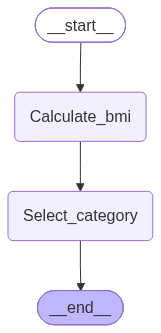

In [31]:
from IPython.display import Image
Image(wf.get_graph().draw_mermaid_png())